# ***Годограф Цыпкина-Поляка. Робастная устойчивость - круг.***

ncffs - a_0, которые записаны в следующем порядке: [a_0, a_1, ..., a_n]
bcffs - alpha, которые записаны в следующм порядке: [alpha_0, alpha_1, ..., alpha_n]

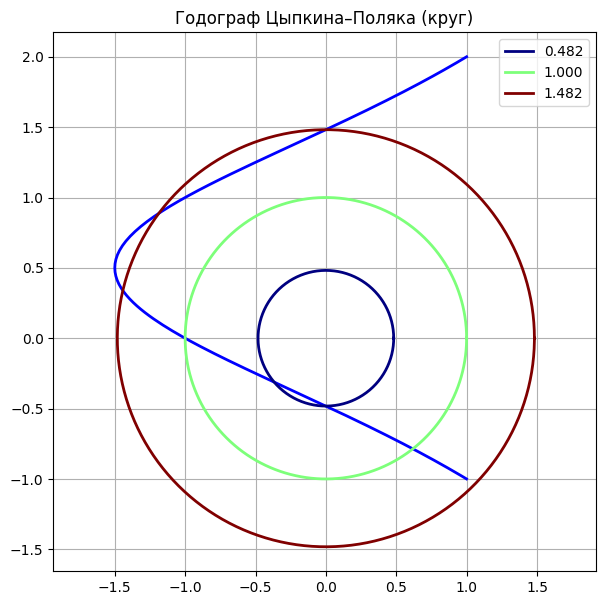

δ*: [0.48198051 1.         1.48198051]


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def robust_stability_disk():

    # Номинальные коэффициенты (ncffs) и веса (bcffs)
    ncffs = np.array([1, 1, 5, 2, 1], dtype=float)
    bcffs = np.array([1, 1, 0, 1, 1], dtype=float)

    polydim = len(ncffs)

    # Формируем U0, Ua (для Re) и V0, Va (для Im)
    u0cffs = np.zeros(polydim)
    uacffs = np.zeros(polydim)

    for k in range(polydim-1, -1, -2):
        power = (polydim - (k+1)) // 2
        u0cffs[k] = ((-1)**power) * ncffs[k]
        uacffs[k] = bcffs[k]

    v0cffs = np.zeros(polydim)
    vacffs = np.zeros(polydim)

    for k in range(polydim-2, -1, -2):
        power = (polydim - 1 - (k+1)) // 2
        v0cffs[k+1] = ((-1)**power) * ncffs[k]
        vacffs[k+1] = bcffs[k]

    # Строим годограф
    count = 5001
    omega_ticks = np.linspace(0, 100, count)
    x_vals = np.zeros(count)
    y_vals = np.zeros(count)

    for i, omega in enumerate(omega_ticks):
        num_x = np.polyval(u0cffs, omega)
        den_x = np.polyval(uacffs, omega)
        num_y = np.polyval(v0cffs, omega)
        den_y = np.polyval(vacffs, omega)

        x_vals[i] = num_x / den_x if den_x != 0 else np.nan
        y_vals[i] = num_y / den_y if den_y != 0 else np.nan

    def polyder(num, den):
        dnum = np.polyder(num)
        dden = np.polyder(den)
        return np.convolve(dnum, den), np.convolve(num, dden)

    unum, uden = polyder(u0cffs, uacffs)
    vnum, vden = polyder(v0cffs, vacffs)

    # Условие X X' + Y Y' = 0 → многочлен
    res = np.convolve(np.convolve(vnum, uden), np.convolve(v0cffs, uacffs)) + \
          np.convolve(np.convolve(unum, vden), np.convolve(u0cffs, vacffs))

    # Находим корни
    rts = np.roots(res)
    rts = rts[np.isreal(rts)]
    rts = np.real(rts)
    rts = rts[rts > 0]

    # Считаем δ
    deltas = []
    for w in rts:
        x = np.polyval(u0cffs, w) / np.polyval(uacffs, w)
        y = np.polyval(v0cffs, w) / np.polyval(vacffs, w)
        deltas.append(np.sqrt(x**2 + y**2))

    deltas = np.array(deltas)

    plt.figure(figsize=(7, 7))
    plt.plot(x_vals, y_vals, 'b', linewidth=2)

    phi = np.linspace(0, 2*np.pi, 500)
    colors = plt.cm.jet(np.linspace(0, 1, max(len(deltas), 1)))

    for i, delta in enumerate(deltas):
        plt.plot(delta*np.cos(phi), delta*np.sin(phi),
                 color=colors[i], linewidth=2, label=f"{delta:.3f}")

    plt.grid(True)
    plt.axis('equal')
    plt.legend()
    plt.title("Годограф Цыпкина–Поляка (круг)")
    plt.show()

    return deltas

if __name__ == "__main__":
    deltas = robust_stability_disk()
    print("δ*:", deltas)

# **Из чисел, которые представлены на сетке с разными цветами, совпадающими с цветами квадратов, нужно выбрать минимальное, так как это уже δ***

Данный скрипт находит все точки касания годографа и кругов с радиусом δ*. Для нахождения радиуса робастной устойчивости δmax следует в конце воспользоваться следующей формулой:    δmax = min{δ*; a0_0/alpha_0; an_0/alpha_n}, где δ* - размер наибольшего квадрата вписанного в годограф.